In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv(r'c:\Users\rajku\Downloads\archive (1)\Titanic-Dataset.csv', usecols=(['Age', 'Fare', 'Survived']))

In [ ]:
df.dropna(inplace=True)         # remocing missing val

In [4]:
print(df.shape)
print(df.head())

(714, 3)
   Survived   Age     Fare
0         0  22.0   7.2500
1         1  38.0  71.2833
2         1  26.0   7.9250
3         1  35.0  53.1000
4         0  35.0   8.0500


In [5]:
x = df[['Age', 'Fare']] 
y = df['Survived']

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2)
print(x_train.head(2))

      Age      Fare
88   23.0  263.0000
202  34.0    6.4958


In [28]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print(accuracy_score(y_pred, y_test)*100)

64.33566433566433


In [29]:
print(np.mean(cross_val_score(clf, x,y,cv=10,scoring='accuracy'))*100)

63.30985915492957


In [30]:
kbin_age = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='quantile')
kbin_fare= KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='quantile')

In [31]:
trf = ColumnTransformer([
    ('first', kbin_age, [0]),
    ('second',kbin_fare, [1])
])

In [32]:
x_train_transform = trf.fit_transform(x_train)
x_test_transform = trf.fit_transform(x_test)

In [33]:
# trf.named_transformers_['first'].n_bins_
# trf.named_transformers_
trf.named_transformers_['first'].bin_edges_


array([array([ 0.83,  8.1 , 16.  , 18.  , 19.  , 20.  , 21.  , 22.  , 23.4 ,
              25.  , 28.  , 29.  , 30.2 , 32.  , 35.  , 36.  , 39.  , 43.7 ,
              48.8 , 57.8 , 71.  ])                                         ],
      dtype=object)

In [34]:
output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_transform[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_transform[:,1]
})

output['age_labels'] = pd.cut(x=x_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=x_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [35]:

output.head(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
88,23.0,6.0,263.0000,19.0,"(22.0, 23.4]","(113.036, 512.329]"
202,34.0,13.0,6.4958,0.0,"(32.0, 35.0]","(0.0, 7.225]"
2,26.0,8.0,7.9250,4.0,"(25.0, 28.0]","(7.91, 7.925]"
85,33.0,12.0,15.8500,9.0,"(32.0, 35.0]","(14.459, 18.75]"
845,42.0,16.0,7.5500,1.0,"(39.0, 43.7]","(7.225, 7.75]"


In [36]:
dt = DecisionTreeClassifier()
dt.fit(x_train_transform, y_train)
y_predb = dt.predict(x_test)

c:\Users\rajku\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [37]:
print(accuracy_score(y_predb , y_test)*100)

62.23776223776224


In [38]:
print(np.mean(cross_val_score(dt, x,y,cv=10,scoring='accuracy')))

0.6345070422535211


In [20]:
# code to get accuracy and graphs
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.6316901408450704


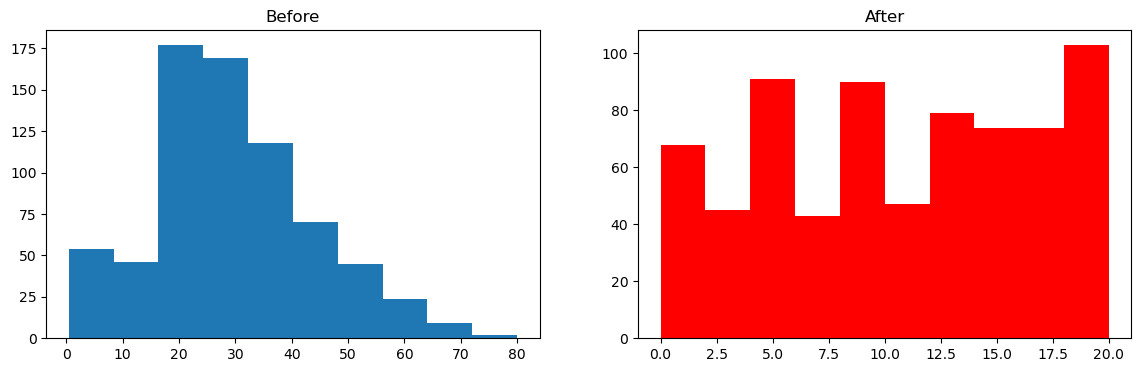

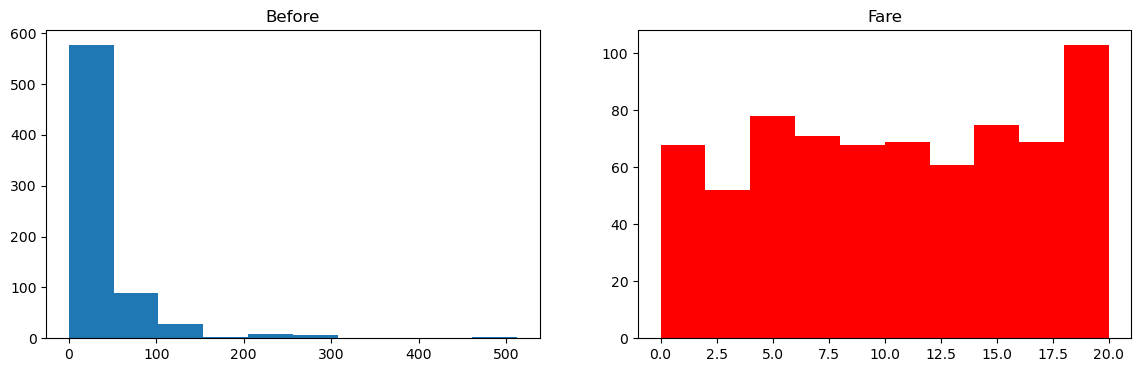

In [117]:
discretize(21, 'quantile')